In [2]:
from few.amplitude.romannet import RomanAmplitude
from few.waveform import FastSchwarzschildEccentricFlux
from few.utils.utility import get_fundamental_frequencies
from few.utils.ylm import GetYlms
from few.summation.interpolatedmodesum import CubicSplineInterpolant
from few.summation.interpolatedmodesum import InterpolatedModeSum
from few.utils.constants import *
from few.trajectory.inspiral import EMRIInspiral
from scipy import special 
import numpy as np
import matplotlib.pyplot as plt
from pycbc.types import TimeSeries
from pycbc.types import FrequencySeries
import gwmat
from gwmat import injection1
unlensed_emri_waveform = injection1.generate_unlensed_emri_waveforms()
print(unlensed_emri_waveform)

print(unlensed_emri_waveform["hc_FD_Unlensed"])


/home/mayank/miniconda3/envs/few_env/lib/python3.12/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


td_hc : [1.08564233e-22 1.11315730e-22 1.12800954e-22 ... 1.18379614e-22
 1.92439741e-22 2.54788187e-22]
td_hp : [-3.35499608e-23 -2.10951991e-23 -8.40043552e-24 ... -3.35972728e-22
 -2.95006727e-22 -2.36024518e-22]
{'frequency_array': <pycbc.types.array.Array object at 0x72496c454260>, 'hp_TD_Unlensed': <pycbc.types.timeseries.TimeSeries object at 0x72496ced7ec0>, 'hc_TD_Unlensed': <pycbc.types.timeseries.TimeSeries object at 0x72496ad02450>, 'hp_FD_Unlensed': <pycbc.types.frequencyseries.FrequencySeries object at 0x72496d0a4050>, 'hc_FD_Unlensed': <pycbc.types.frequencyseries.FrequencySeries object at 0x72496a720c80>}
[-4.15570412e-21+0.00000000e+00j -4.15570411e-21+3.34808376e-25j
 -4.15570409e-21+6.69613949e-25j ... -8.78153638e-22+7.18761208e-27j
 -8.78153642e-22+3.60284669e-27j -8.78153654e-22+0.00000000e+00j]


In [3]:
m1=m2=30
init_prms = dict(f_start=20., sample_rate=2048, wf_approximant="IMRPhenomXP")
lens_prms = dict(m_lens=10000000, y_lens=1, z_lens=0)
cbc_prms = dict(mass_1=m1, mass_2=m2, a_1=0, a_2=0, tilt_1=0, tilt_2=0, phi_12=0, phi_jl=0, 
                luminosity_distance=2000, theta_jn=0,
                coa_phase=0, rwrap=0.0)
prms = {**init_prms, **lens_prms, **cbc_prms}


In [4]:
emri_waveforms = injection1.generate_gw_polarizations_hp_hc_emri(**prms)

Neither `polarization` nor `psi` found in dictionary. Setting it to `0.0` by default.
Neither `trigger_time` nor `geocent_time` found in dictionary. Setting it to `0.0` by default.
td_hc : [1.08564233e-22 1.11315730e-22 1.12800954e-22 ... 1.18379614e-22
 1.92439741e-22 2.54788187e-22]
td_hp : [-3.35499608e-23 -2.10951991e-23 -8.40043552e-24 ... -3.35972728e-22
 -2.95006727e-22 -2.36024518e-22]
step1 done
<class 'dict'>
{'frequency_array': <pycbc.types.array.Array object at 0x72496ad00230>, 'hp_TD_Unlensed': <pycbc.types.timeseries.TimeSeries object at 0x72496ab3a510>, 'hc_TD_Unlensed': <pycbc.types.timeseries.TimeSeries object at 0x72496a748080>, 'hp_FD_Unlensed': <pycbc.types.frequencyseries.FrequencySeries object at 0x72496a7482c0>, 'hc_FD_Unlensed': <pycbc.types.frequencyseries.FrequencySeries object at 0x72496a748470>}
Print unlensed waveform emri TD shape (862752,)
amplification factor : (431377,) , (431377,)
Lensed_arrays : ((431377,), (431377,))
Lensed_Pycbc_Object_fd_hp : (4313

In [5]:
old_waveform = injection1.generate_gw_polarizations_hp_hc(**prms)

(4096,)
amplification factor : (2049,) , (2049,)
Lensed_arrays : ((2049,), (2049,))
Lensed_Pycbc_Object_fd_hp : (2049,)
Lensed_Pycbc_Object_fd_hp : (2049,)
rwrap value : 0.0
lensed_td_hp : [ 6.28773541e-23  2.39250403e-23 -2.05905055e-23 ...  1.15784066e-22
  1.10311729e-22  9.24212294e-23], lensed_fd_hp: [4.93749996e-27+0.00000000e+00j 3.41549824e-27-3.77602393e-27j
 1.27957928e-27-4.22362776e-27j ... 2.53972271e-33+7.34192053e-34j
 2.80844960e-33+3.91538003e-35j 2.65042901e-33-7.19633889e-34j]
lensed_td_hp shape: (4096,), lensed_fd_hp shape: (2049,), unlensed_td_hp_shape: (4096,), unlensed_fd_hp_shape: (2049,)
(4096,)
lensed_waveforms hc : [1.03124492e-22 1.20395155e-22 1.23167289e-22 ... 2.51350463e-24
 3.99772173e-23 7.49309862e-23]
lensed_waveforms hp : [ 6.28773541e-23  2.39250403e-23 -2.05905055e-23 ...  1.15784066e-22
  1.10311729e-22  9.24212294e-23]


In [6]:
print(emri_waveforms["frequency_array"].shape)
print(prms["m_lens"])
print(emri_waveforms["hp_FD_Unlensed"].shape)

(431377,)
10000000
(431377,)


[-1.43044467e-21+0.00000000e+00j -1.43044463e-21-2.10964570e-26j
 -1.43044452e-21-4.22024598e-26j ...  8.13579257e-22-4.78164863e-27j
  8.13579252e-22-2.39676124e-27j  8.13579260e-22+0.00000000e+00j]


/tmp/ipykernel_16817/750353499.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  amplitude_np = np.array(amplitude_hp)
/tmp/ipykernel_16817/750353499.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  amplitude_nc = np.array(amplitude_hc)
/home/mayank/miniconda3/envs/few_env/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/mayank/miniconda3/envs/few_env/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


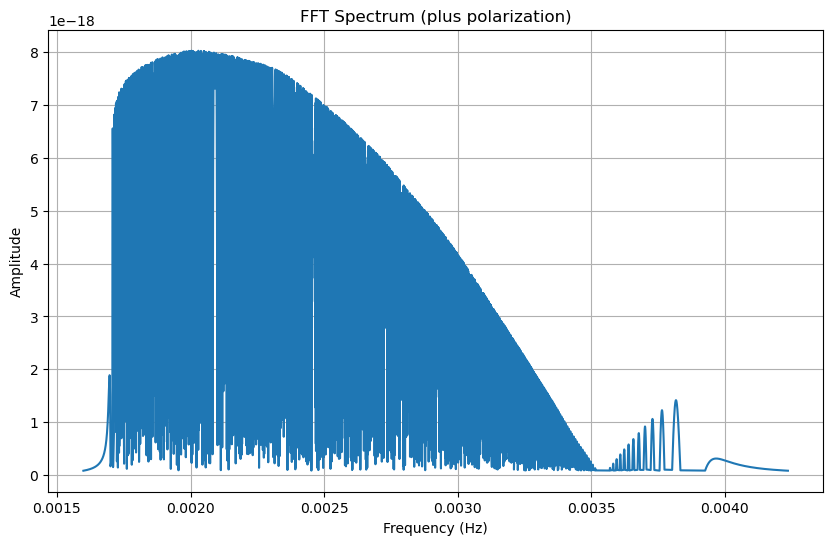

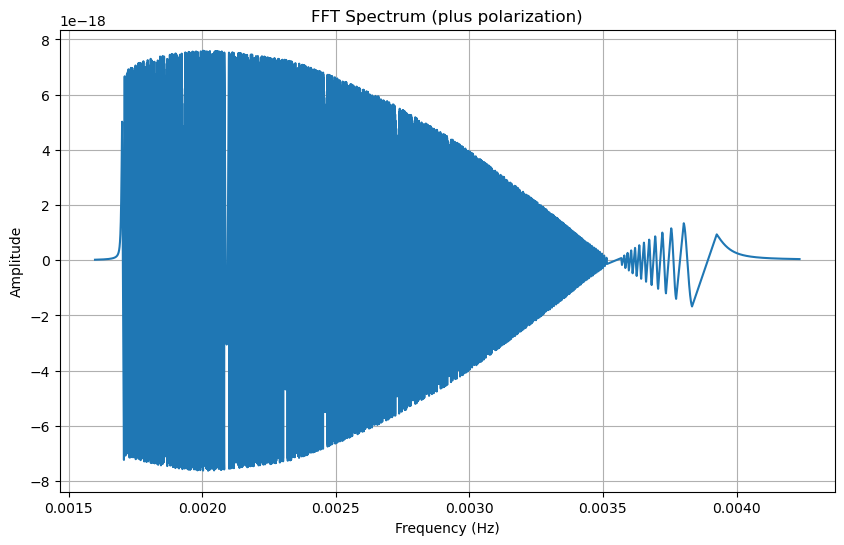

In [7]:
amplitude_hp = (emri_waveforms["hp_FD_Unlensed"])
amplitude_np = np.array(amplitude_hp)
print(amplitude_np)
threshold = 0.01 * np.max(amplitude_np)  # 1% of max amplitude
mask = amplitude_np > threshold
amplitude_hc = (emri_waveforms["hc_FD_Unlensed"])
amplitude_nc = np.array(amplitude_hc)

plt.figure(figsize=(10, 6))
plt.plot(emri_waveforms["frequency_array"][mask], emri_waveforms["hp_FD_Unlensed"][mask])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('FFT Spectrum (plus polarization)')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(emri_waveforms["frequency_array"][mask], emri_waveforms["hc_FD_Unlensed"][mask])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('FFT Spectrum (plus polarization)')
plt.grid(True)
plt.show()

(431377,) (431377,) (431377,)
[-1.43044467e-21-4.15570412e-21j -1.43077944e-21-4.15572520e-21j
 -1.43111413e-21-4.15574629e-21j ...  8.13572069e-22-8.78158420e-22j
  8.13575650e-22-8.78156039e-22j  8.13579260e-22-8.78153654e-22j]
[4.39500269e-21 4.39513160e-21 4.39526050e-21 ... 1.19710556e-21
 1.19710625e-21 1.19710695e-21]


/tmp/ipykernel_16817/1981763922.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  fft_wave = np.array(fft_wave_total)


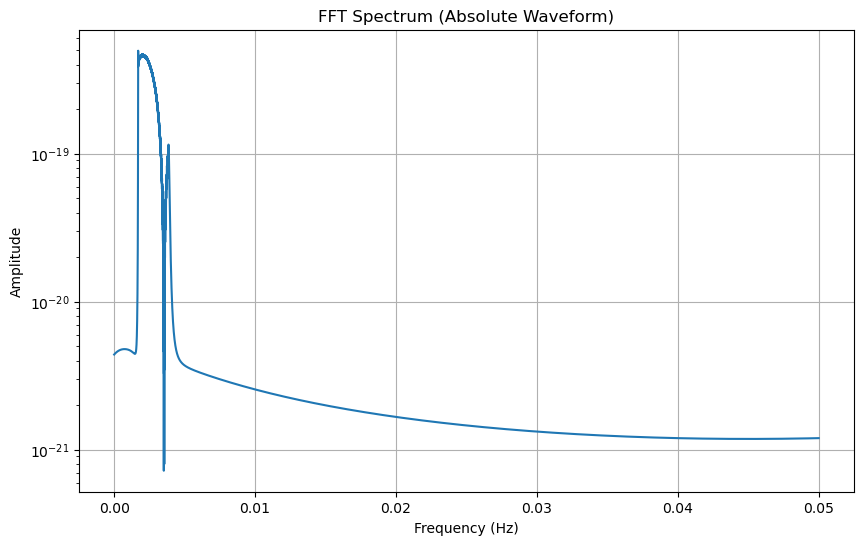

In [8]:
#check 1 with the few package
freq_fft = emri_waveforms["frequency_array"]
fft_wave_hp = emri_waveforms["hp_FD_Unlensed"]
fft_wave_hc = 1j*emri_waveforms["hc_FD_Unlensed"]
print(fft_wave_hc.shape, fft_wave_hp.shape, freq_fft.shape)
fft_wave_total = fft_wave_hp + fft_wave_hc
fft_wave = np.array(fft_wave_total)
print(fft_wave)
amplitude = np.abs(fft_wave)
print(amplitude)
threshold = 0.00001 * np.max(amplitude) # 1% of max amplitude
pos_freq_mask = freq_fft >= 0 # Only positive frequencies
amplitude_mask = amplitude > threshold
combined_mask = amplitude_mask
plt.figure(figsize=(10, 6))
plt.plot(freq_fft[combined_mask], amplitude[combined_mask])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('FFT Spectrum (Absolute Waveform)')
plt.yscale('log')
plt.grid(True)
plt.show()

(431377,) (431377,) (431377,)
[-1.43044467e-21-4.15570412e-21j -1.43077944e-21-4.15572520e-21j
 -1.43111413e-21-4.15574629e-21j ...  8.13572069e-22-8.78158420e-22j
  8.13575650e-22-8.78156039e-22j  8.13579260e-22-8.78153654e-22j]
[4.39500269e-21 4.39513160e-21 4.39526050e-21 ... 1.19710556e-21
 1.19710625e-21 1.19710695e-21]


/tmp/ipykernel_16817/2831459048.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  fft_wave = np.array(fft_wave_total)


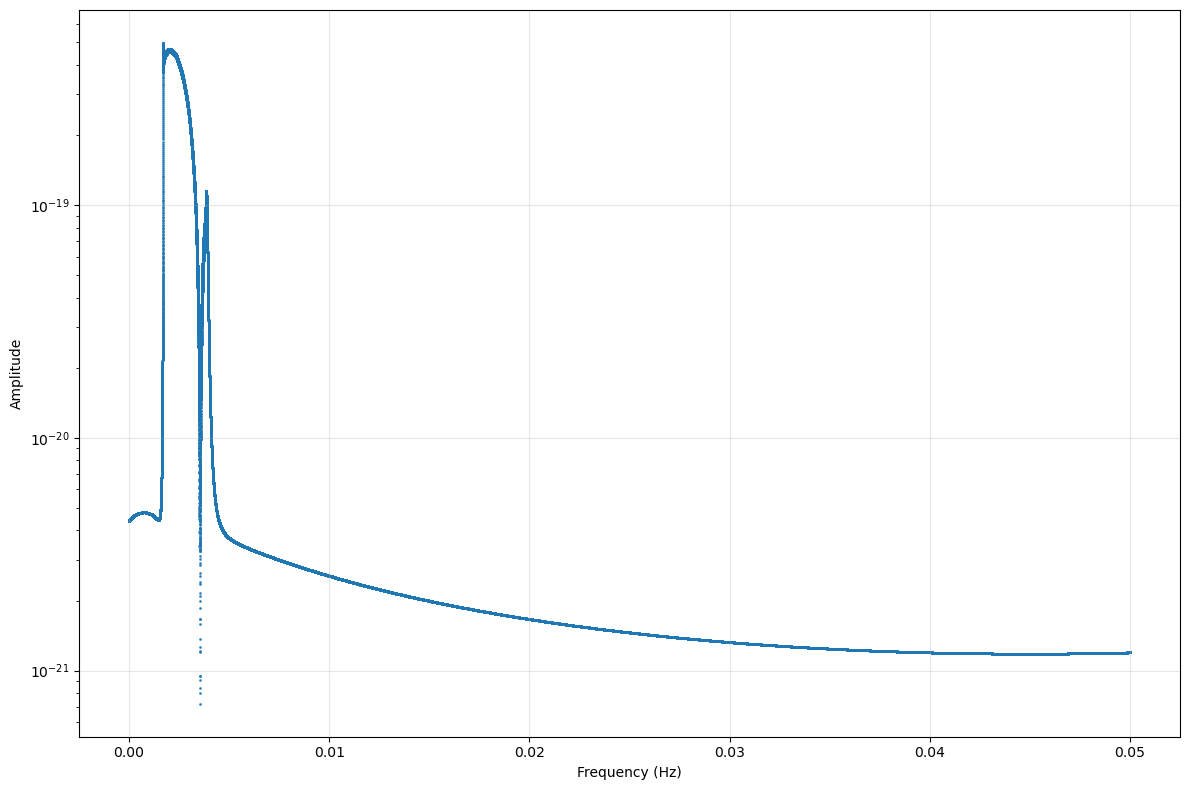

In [9]:
#check 1 with the few package
freq_fft = emri_waveforms["frequency_array"]
fft_wave_hp = emri_waveforms["hp_FD_Unlensed"]
fft_wave_hc = 1j*emri_waveforms["hc_FD_Unlensed"]
print(fft_wave_hc.shape, fft_wave_hp.shape, freq_fft.shape)
fft_wave_total = fft_wave_hp + fft_wave_hc
fft_wave = np.array(fft_wave_total)
print(fft_wave)
amplitude = np.abs(fft_wave)
print(amplitude)
threshold = 0.00001 * np.max(amplitude) # 1% of max amplitude
pos_freq_mask = freq_fft >= 0 # Only positive frequencies
amplitude_mask = amplitude > threshold
combined_mask = amplitude_mask

plt.figure(figsize=(12, 8))  # Same size as comparison plot
plt.scatter(freq_fft[combined_mask], amplitude[combined_mask], s=1, alpha=0.8)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_16817/438625734.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  amplitude_unlensed = np.abs(np.array(fft_wave_unlensed))
/tmp/ipykernel_16817/438625734.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  amplitude_lensed = np.abs(np.array(fft_wave_lensed))


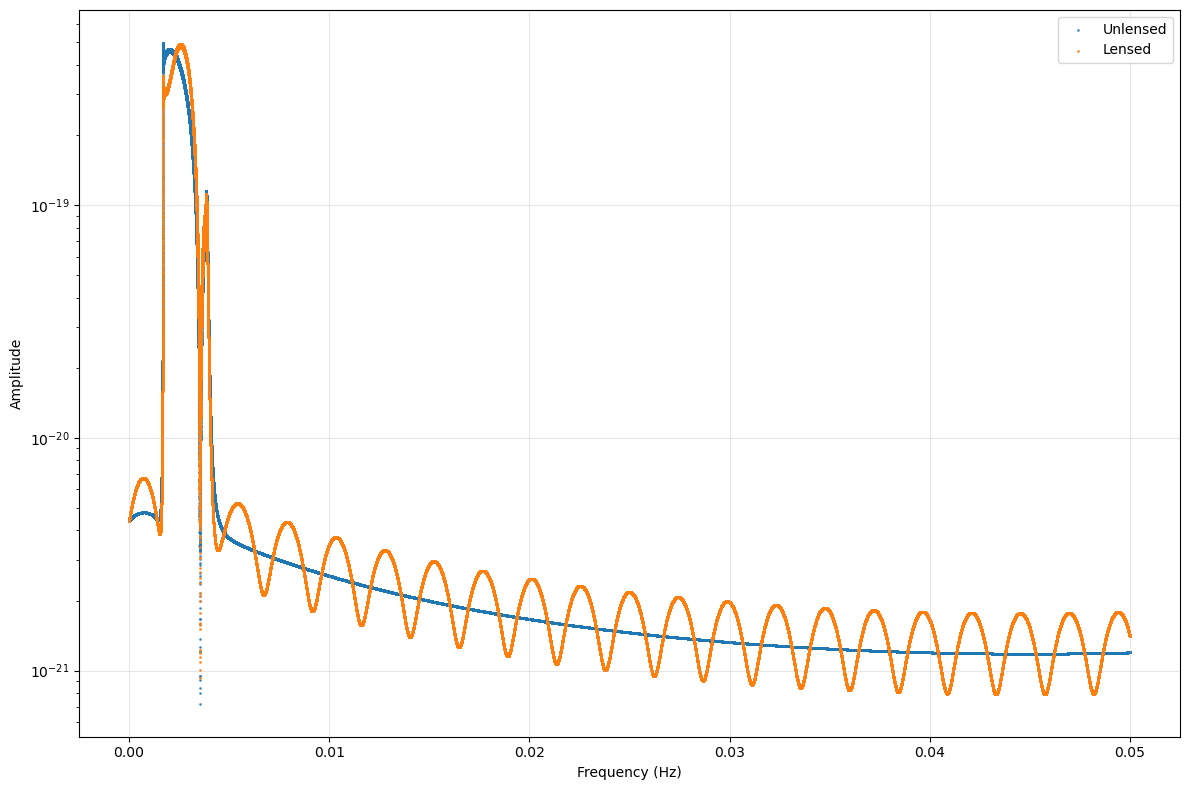

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [10]:
# Get frequency array (same for both)
freq_fft = emri_waveforms["frequency_array"]

# Process unlensed waveform
fft_wave_hp_unlensed = emri_waveforms["hp_FD_Unlensed"]
fft_wave_hc_unlensed = 1j * emri_waveforms["hc_FD_Unlensed"]
fft_wave_unlensed = fft_wave_hp_unlensed + fft_wave_hc_unlensed
amplitude_unlensed = np.abs(np.array(fft_wave_unlensed))

# Process lensed waveform
fft_wave_hp_lensed = emri_waveforms["hp_FD_Lensed"]
fft_wave_hc_lensed = 1j * emri_waveforms["hc_FD_Lensed"]
fft_wave_lensed = fft_wave_hp_lensed + fft_wave_hc_lensed
amplitude_lensed = np.abs(np.array(fft_wave_lensed))

# Create threshold based on the maximum of both waveforms
max_amplitude_unlensed = float(amplitude_unlensed.max())
max_amplitude_lensed = float(amplitude_lensed.max())
max_amplitude = max(max_amplitude_unlensed, max_amplitude_lensed)
threshold = 0.00001 * max_amplitude

# Create masks for filtering
amplitude_mask_unlensed = amplitude_unlensed > threshold
amplitude_mask_lensed = amplitude_lensed > threshold
# pos_freq_mask = freq_fft >= 0
pos_freq_mask = True
# Combined masks
combined_mask_unlensed = amplitude_mask_unlensed & pos_freq_mask
combined_mask_lensed = amplitude_mask_lensed & pos_freq_mask

# Create the comparison plot
plt.figure(figsize=(12, 8))

# Option 1: Use scatter plot (no connecting lines)
plt.scatter(freq_fft[combined_mask_unlensed], amplitude_unlensed[combined_mask_unlensed], 
           label='Unlensed', alpha=0.7, s=1)
plt.scatter(freq_fft[combined_mask_lensed], amplitude_lensed[combined_mask_lensed], 
           label='Lensed', alpha=0.8, s=1)

# Option 2: Use line plot with NaN insertions to break lines (comment out Option 1 and uncomment this)
# # Create arrays with NaN where mask is False to break the line
# freq_unlensed_plot = np.where(combined_mask_unlensed, freq_fft, np.nan)
# amp_unlensed_plot = np.where(combined_mask_unlensed, amplitude_unlensed, np.nan)
# freq_lensed_plot = np.where(combined_mask_lensed, freq_fft, np.nan)
# amp_lensed_plot = np.where(combined_mask_lensed, amplitude_lensed, np.nan)
# 
# plt.plot(freq_unlensed_plot, amp_unlensed_plot, label='Unlensed', alpha=0.7, linewidth=1.5)
# plt.plot(freq_lensed_plot, amp_lensed_plot, label='Lensed', alpha=0.8, linewidth=1.5)

plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: Plot the ratio to see the lensing effect more clearly
plt.figure(figsize=(12, 6))
# # Use a common mask for both to ensure same frequency points
# common_mask = amplitude_mask_unlensed & amplitude_mask_lensed & pos_freq_mask
# ratio = amplitude_lensed[common_mask] / amplitude_unlensed[common_mask]

# plt.plot(freq_fft[common_mask], ratio)
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Amplitude Ratio (Lensed/Unlensed)')
# plt.title('Gravitational Lensing Effect: Amplitude Ratio')
# plt.grid(True, alpha=0.3)
# plt.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='No lensing (ratio = 1)')
# plt.legend()
# plt.tight_layout()
# plt.show()

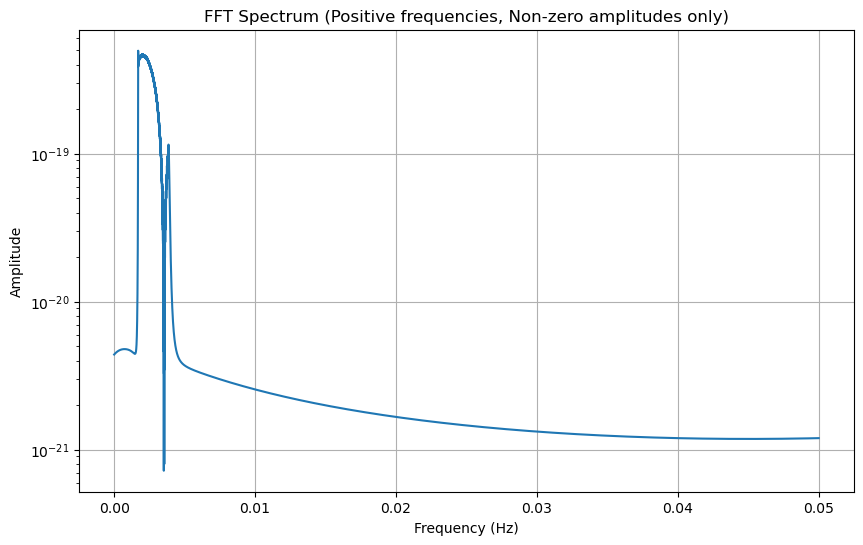

In [10]:
#check 2 with the few package
amplitude = np.abs(fft_wave)
threshold = 0.001 * np.max(amplitude)  # 1% of max amplitude
pos_freq_mask = freq_fft >= 0  # Only positive frequencies
amplitude_mask = amplitude > threshold
combined_mask =   amplitude_mask

plt.figure(figsize=(10, 6))
plt.plot(freq_fft[combined_mask], amplitude[combined_mask])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('FFT Spectrum (Positive frequencies, Non-zero amplitudes only)')
plt.grid(True)
plt.yscale('log')

plt.show()

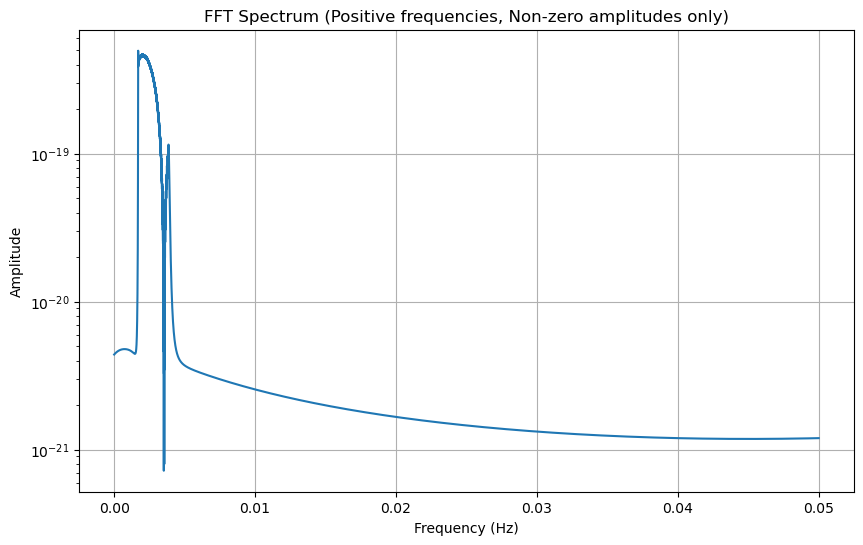

In [11]:
#check 3 with the few package
amplitude = np.abs(fft_wave)
threshold = 0.00001 * np.max(amplitude) # 1% of max amplitude
pos_freq_mask = freq_fft >= 0 # Only positive frequencies
amplitude_mask = amplitude > threshold
combined_mask = amplitude_mask
plt.figure(figsize=(10, 6))
plt.plot(freq_fft[combined_mask], amplitude[combined_mask])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('FFT Spectrum (Positive frequencies, Non-zero amplitudes only)')
plt.yscale('log')
plt.grid(True)
plt.show()

[]

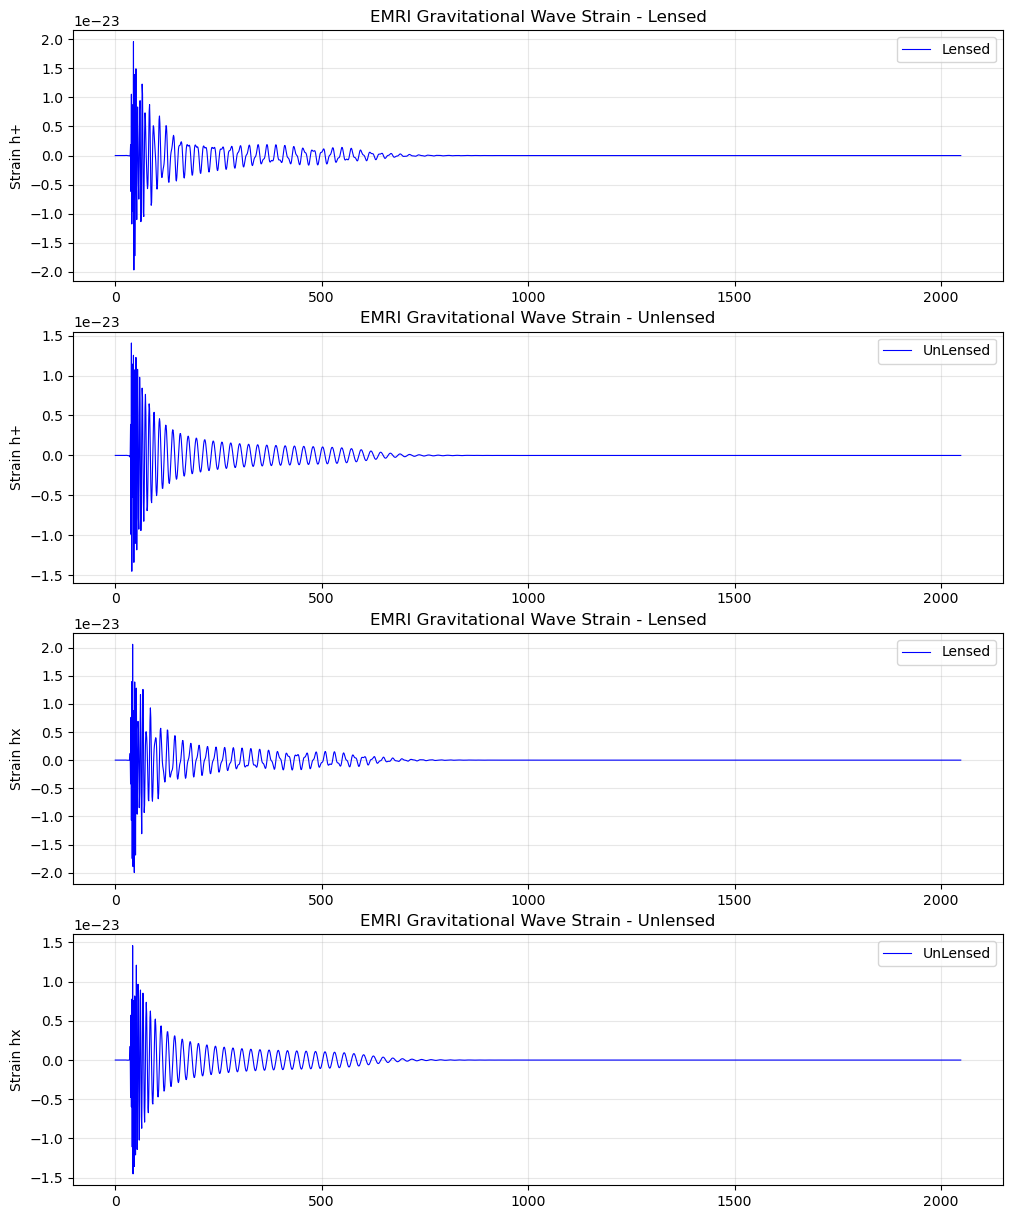

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(12, 15))
axes[0].plot(old_waveform["hp_FD_Lensed"], 'b-', linewidth=0.8, label='Lensed')
axes[0].set_ylabel('Strain h+')
axes[0].set_title('EMRI Gravitational Wave Strain - Lensed')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[1].plot(old_waveform["hp_FD_Unlensed"], 'b-', linewidth=0.8, label='UnLensed')
axes[1].set_ylabel('Strain h+')
axes[1].set_title('EMRI Gravitational Wave Strain - Unlensed')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[2].plot(old_waveform["hc_FD_Lensed"], 'b-', linewidth=0.8, label='Lensed')
axes[2].set_ylabel('Strain hx')
axes[2].set_title('EMRI Gravitational Wave Strain - Lensed')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[3].plot(old_waveform["hc_FD_Unlensed"], 'b-', linewidth=0.8, label='UnLensed')
axes[3].set_ylabel('Strain hx')
axes[3].set_title('EMRI Gravitational Wave Strain - Unlensed')
axes[3].grid(True, alpha=0.3)
axes[3].legend()

plt.plot()

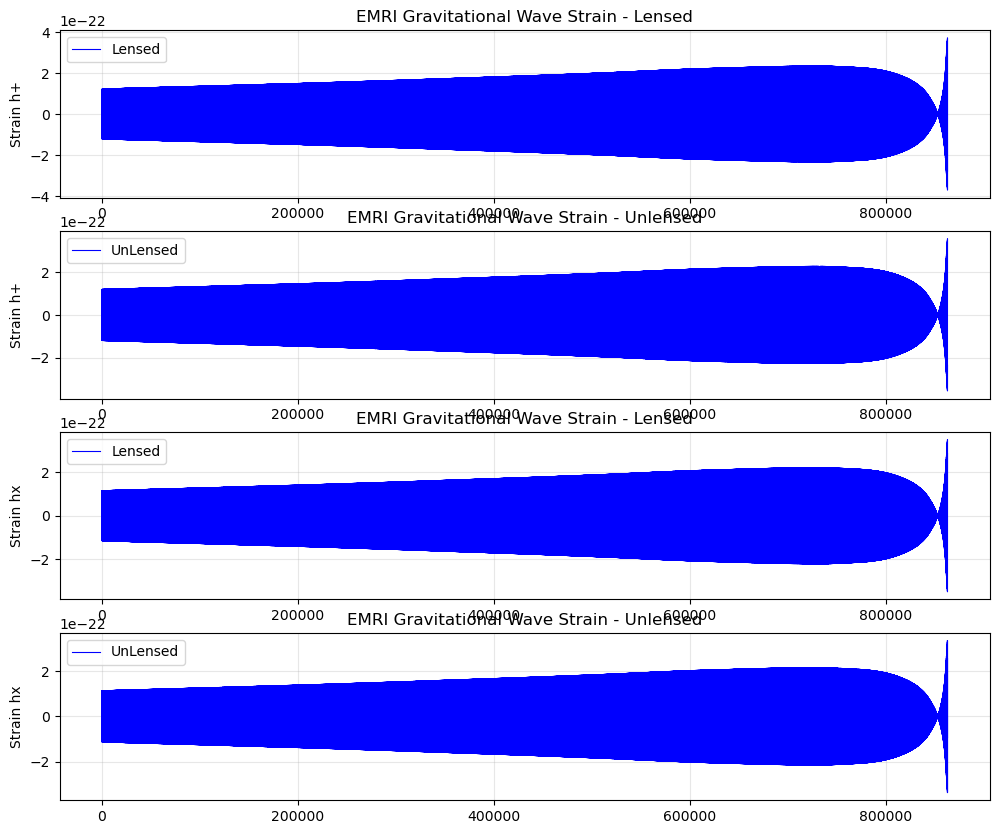

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10))
axes[0].plot(emri_waveforms["hp_TD_Lensed"], 'b-', linewidth=0.8, label='Lensed')
axes[0].set_ylabel('Strain h+')
axes[0].set_title('EMRI Gravitational Wave Strain - Lensed')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[1].plot(emri_waveforms["hp_TD_Unlensed"], 'b-', linewidth=0.8, label='UnLensed')
axes[1].set_ylabel('Strain h+')
axes[1].set_title('EMRI Gravitational Wave Strain - Unlensed')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[2].plot(emri_waveforms["hc_TD_Lensed"], 'b-', linewidth=0.8, label='Lensed')
axes[2].set_ylabel('Strain hx')
axes[2].set_title('EMRI Gravitational Wave Strain - Lensed')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[3].plot(emri_waveforms["hc_TD_Unlensed"], 'b-', linewidth=0.8, label='UnLensed')
axes[3].set_ylabel('Strain hx')
axes[3].set_title('EMRI Gravitational Wave Strain - Unlensed')
axes[3].grid(True, alpha=0.3)
axes[3].legend()



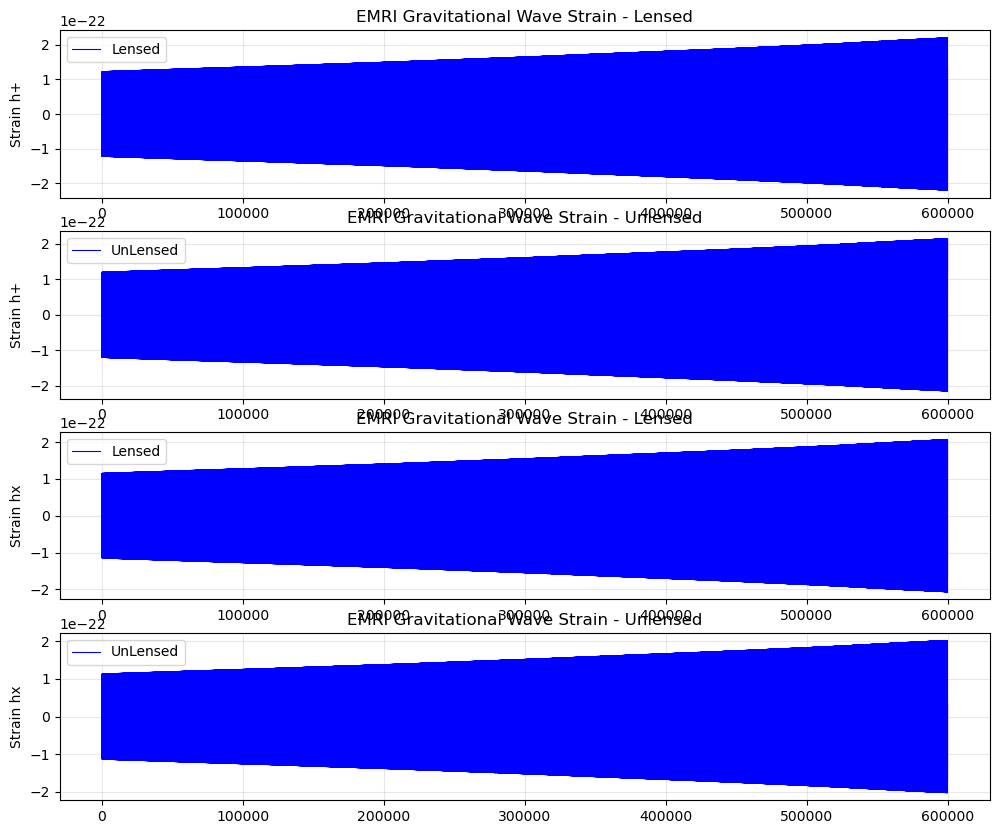

In [24]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10))
axes[0].plot(emri_waveforms["hp_TD_Lensed"][0:600000], 'b-', linewidth=0.8, label='Lensed')
axes[0].set_ylabel('Strain h+')
axes[0].set_title('EMRI Gravitational Wave Strain - Lensed')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[1].plot(emri_waveforms["hp_TD_Unlensed"][0:600000], 'b-', linewidth=0.8, label='UnLensed')
axes[1].set_ylabel('Strain h+')
axes[1].set_title('EMRI Gravitational Wave Strain - Unlensed')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[2].plot(emri_waveforms["hc_TD_Lensed"][0:600000], 'b-', linewidth=0.8, label='Lensed')
axes[2].set_ylabel('Strain hx')
axes[2].set_title('EMRI Gravitational Wave Strain - Lensed')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[3].plot(emri_waveforms["hc_TD_Unlensed"][0:600000], 'b-', linewidth=0.8, label='UnLensed')
axes[3].set_ylabel('Strain hx')
axes[3].set_title('EMRI Gravitational Wave Strain - Unlensed')
axes[3].grid(True, alpha=0.3)
axes[3].legend()

In [23]:
import pycbc 
# Check the current data types
print("Data type of hc_FD_Lensed:", emri_waveforms["hc_FD_Lensed"].dtype)
print("Data type of hc_FD_Unlensed:", emri_waveforms["hc_FD_Unlensed"].dtype) # change this in the few call when using the 

# Convert to double complex (complex128)
hc_FD_lensed_double = emri_waveforms["hc_FD_Lensed"][0:600000].astype(np.complex128)
hc_FD_unlensed_double = emri_waveforms["hc_FD_Unlensed"][0:600000].astype(np.complex128)
hc_TD_lensed_double = emri_waveforms["hc_TD_Lensed"][0:600000]
hc_TD_unlensed_double = emri_waveforms["hc_TD_Unlensed"][0:600000]
print(hc_FD_lensed_double)
print(f"hc_TD_lensed_double : {hc_TD_lensed_double}")
print(f"hc_TD_lensed : {emri_waveforms["hc_TD_Lensed"]}")
print(hc_TD_lensed_double.shape, hc_TD_unlensed_double.shape)
LISA_psd = pycbc.psd.from_txt("/home/mayank/test_waveform/gwmat-main/gwmat/detector_PSDs/lisa_psd.txt",length=int(1/emri_waveforms["hp_FD_Lensed"].delta_f),delta_f=emri_waveforms["hp_FD_Lensed"].delta_f,low_freq_cutoff=1e-5,is_asd_file=False)
try:
    match_result = pycbc.filter.matchedfilter.match(
        hc_TD_lensed_double, 
        hc_TD_unlensed_double,
        psd=LISA_psd,
        low_frequency_cutoff=1e-5,
        high_frequency_cutoff=None
    )
    print("Match successful")
    print("Match result:", match_result)
except Exception as e:
    print("Error in match function:", e)

try:
    match_result = pycbc.filter.matchedfilter.match(
        hc_FD_lensed_double,
        hc_FD_unlensed_double,
        psd=LISA_psd,
        low_frequency_cutoff=1e-5,
        high_frequency_cutoff=None
    )
    print("Match successful")
    print("Match result:", match_result)
except Exception as e:
    print("Error in match function:", e)


Data type of hc_FD_Lensed: complex128
Data type of hc_FD_Unlensed: complex128
[-4.15570412e-21+0.00000000e+00j -4.15570879e-21+3.73537862e-25j
 -4.15571344e-21+7.42940550e-25j ... -1.19947166e-21+2.86844535e-23j
 -1.19947218e-21+2.86788790e-23j -1.19947272e-21+2.86732801e-23j]
hc_TD_lensed_double : [ 1.08847604e-22  1.12241549e-22  1.14441873e-22 ... -1.28204001e-22
 -1.50729119e-22 -1.69948341e-22]
hc_TD_lensed : [1.08847604e-22 1.12241549e-22 1.14441873e-22 ... 1.07180953e-22
 1.88319016e-22 2.85258670e-22]
(600000,) (600000,)
Match successful
Match result: (np.float64(nan), np.int64(0))
Match successful
Match result: (np.float64(0.9999779901726958), np.int64(0))


[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.82589131e-73
 2.82587393e-73 2.82585655e-73]


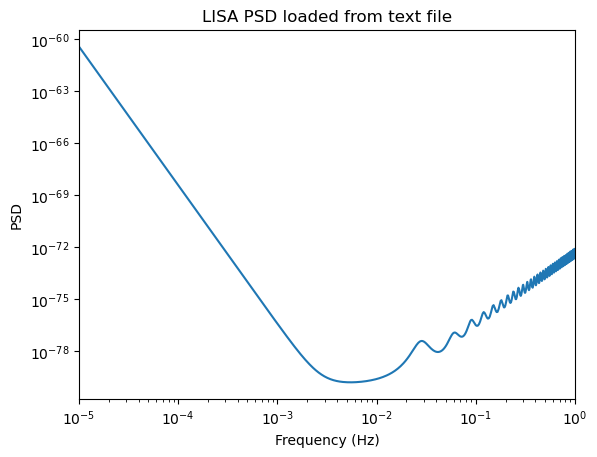

In [17]:
psd = pycbc.psd.from_txt("/home/mayank/test_waveform/gwmat-main/gwmat/detector_PSDs/lisa_psd.txt",length=int(1/emri_waveforms["hp_FD_Lensed"].delta_f),delta_f=emri_waveforms["hp_FD_Lensed"].delta_f,low_freq_cutoff=1e-5,is_asd_file=True)
print(psd)
plt.loglog(psd.sample_frequencies, psd)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.title('LISA PSD loaded from text file')
plt.xlim(1e-5, 1)
plt.show()

In [16]:
import pycbc
import numpy as np

# Keep the TimeSeries objects with their original real data type
# And slice them to the desired length
hc_TD_lensed_sliced = emri_waveforms["hc_TD_Lensed"][0:600000]
hc_TD_unlensed_sliced = emri_waveforms["hc_TD_Unlensed"][0:600000]

# Correctly calculate parameters for the PSD
# The length should be N/2 + 1 for the FFT of the time series
psd_length = len(hc_TD_lensed_sliced) // 2 + 1 
# The delta_f depends on the duration of the sliced waveform
psd_delta_f = 1.0 / hc_TD_lensed_sliced.duration 

# Create the PSD with the correct length and delta_f
# is_asd_file should be False for lisa_psd.txt
LISA_psd = pycbc.psd.from_txt(
    "/home/mayank/test_waveform/gwmat-main/gwmat/detector_PSDs/lisa_psd.txt",
    length=psd_length,
    delta_f=psd_delta_f,
    low_freq_cutoff=1e-5,
    is_asd_file=False  # This file contains PSD, not ASD
)

try:
    # Use the real-valued sliced waveforms
    match_result = pycbc.filter.matchedfilter.match(
        hc_TD_lensed_sliced, 
        hc_TD_unlensed_sliced,
        psd=LISA_psd,
        low_frequency_cutoff=1e-5,
        high_frequency_cutoff=None
    )
    print("Match successful for TimeSeries")
    print("Match result:", match_result)
except Exception as e:
    print("Error in TimeSeries match function:", e)

# For the FrequencySeries match, ensure you are not slicing beyond its length
fd_len = len(emri_waveforms["hc_FD_Lensed"])
hc_FD_lensed_double = emri_waveforms["hc_FD_Lensed"][0:fd_len]
hc_FD_unlensed_double = emri_waveforms["hc_FD_Unlensed"][0:fd_len]

try:
    match_result_fd = pycbc.filter.matchedfilter.match(
        hc_FD_lensed_double,
        hc_FD_unlensed_double,
        psd=LISA_psd,
        low_frequency_cutoff=1e-5,
        high_frequency_cutoff=None
    )
    print("Match successful for FrequencySeries")
    print("Match result:", match_result_fd)
except Exception as e:
    print("Error in FrequencySeries match function:", e)



Match successful for TimeSeries
Match result: (np.float64(0.9999954468132509), np.int64(0))
Error in FrequencySeries match function: lengths do not match (431290 vs 299915)


In [18]:
print(emri_waveforms["hp_FD_Lensed"])

[-1.43044467e-21+0.00000000e+00j -1.43044624e-21-7.76544385e-27j
 -1.43044774e-21-1.69631554e-26j ...  1.11126945e-21-2.65725990e-23j
  1.11126990e-21-2.65687130e-23j  1.11127036e-21-2.65648112e-23j]


In [19]:
import pycbc 
from pycbc import *
pycbc.filter.matchedfilter.match(old_waveform["hc_FD_Unlensed"], old_waveform["hc_FD_Lensed"],psd=None,low_frequency_cutoff=20,high_frequency_cutoff=None)

(np.float64(0.9396461121326981), np.int64(0))

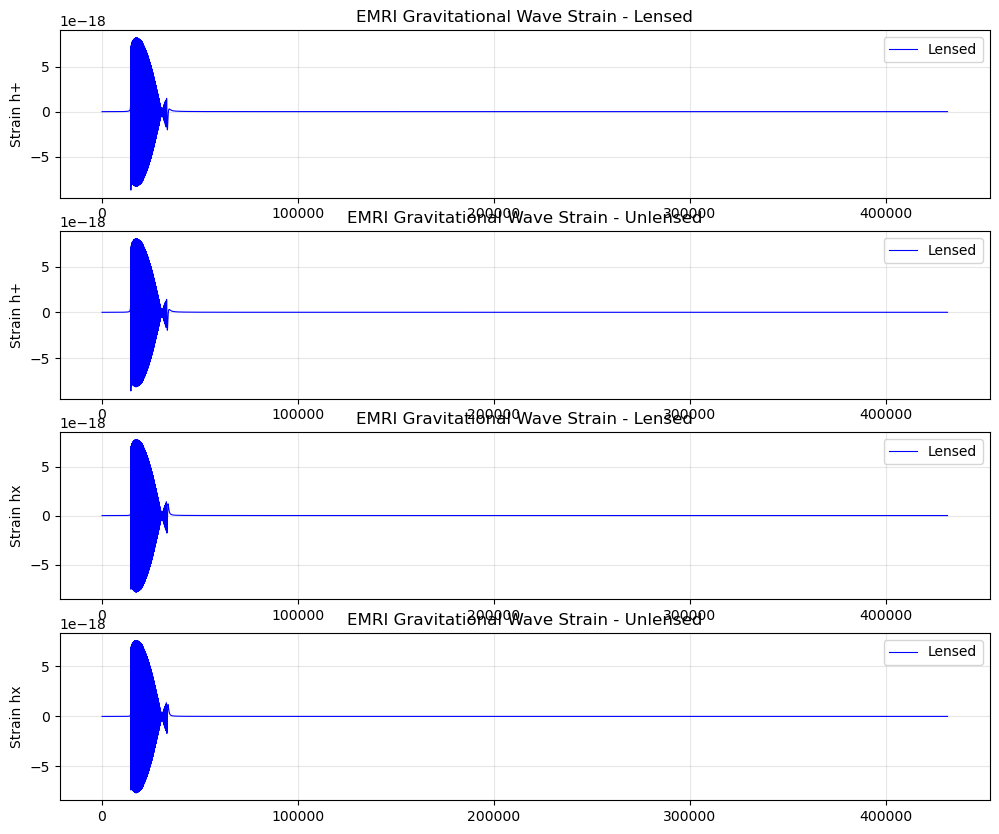

In [20]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10))
axes[0].plot(emri_waveforms["hp_FD_Lensed"], 'b-', linewidth=0.8, label='Lensed')
axes[0].set_ylabel('Strain h+')
axes[0].set_title('EMRI Gravitational Wave Strain - Lensed')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[1].plot(emri_waveforms["hp_FD_Unlensed"], 'b-', linewidth=0.8, label='Lensed')
axes[1].set_ylabel('Strain h+')
axes[1].set_title('EMRI Gravitational Wave Strain - Unlensed')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[2].plot(emri_waveforms["hc_FD_Lensed"], 'b-', linewidth=0.8, label='Lensed')
axes[2].set_ylabel('Strain hx')
axes[2].set_title('EMRI Gravitational Wave Strain - Lensed')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[3].plot(emri_waveforms["hc_FD_Unlensed"], 'b-', linewidth=0.8, label='Lensed')
axes[3].set_ylabel('Strain hx')
axes[3].set_title('EMRI Gravitational Wave Strain - Unlensed')
axes[3].grid(True, alpha=0.3)
axes[3].legend()



(862752,) (862752,)


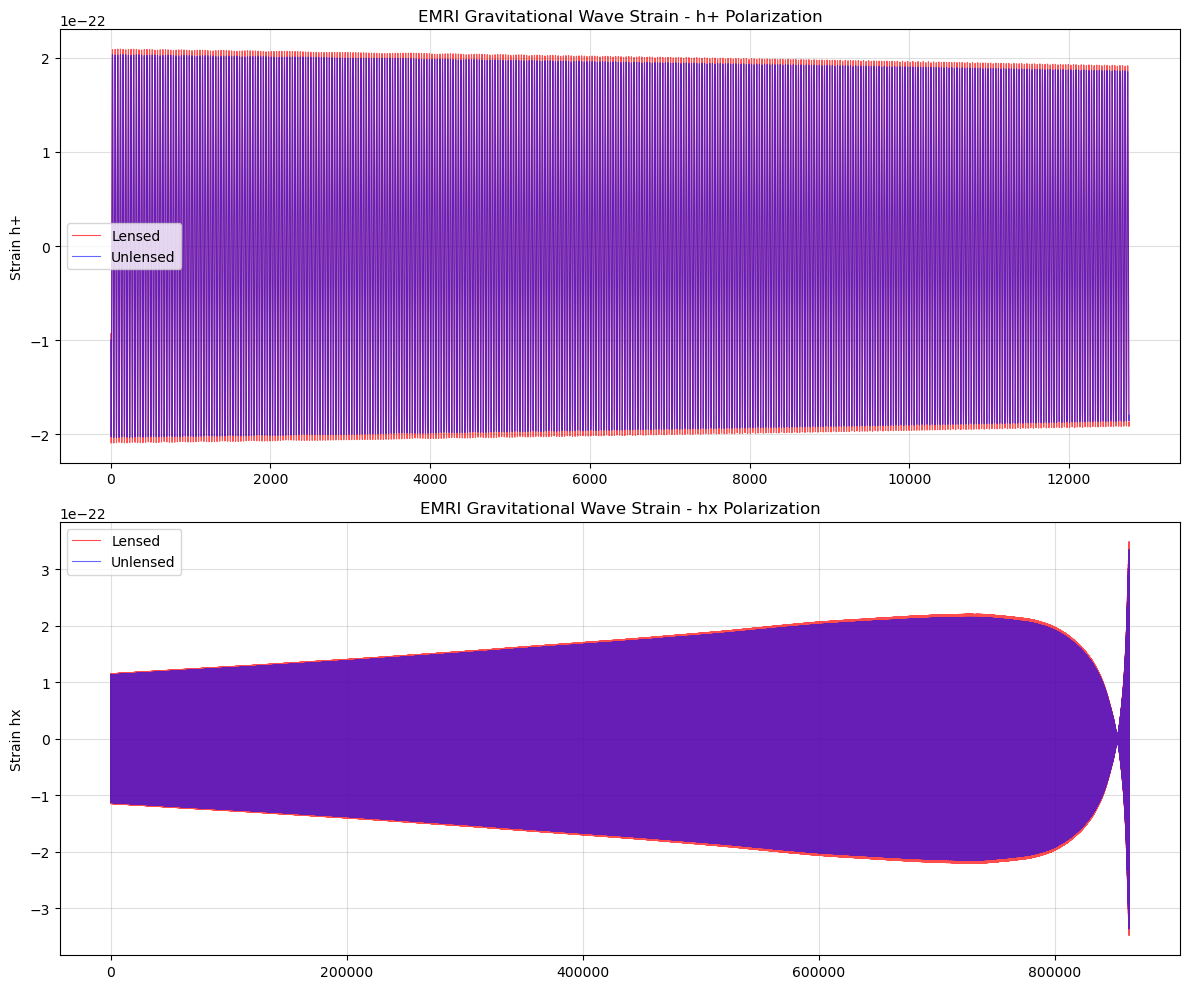

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot h+ polarization
axes[0].plot(emri_waveforms["hp_TD_Lensed"][800000:812752], 'r-', linewidth=0.8, label='Lensed', alpha=0.7)
axes[0].plot(emri_waveforms["hp_TD_Unlensed"][800000:812752], 'b-', linewidth=0.8, label='Unlensed', alpha=0.6)
axes[0].set_ylabel('Strain h+')
axes[0].set_title('EMRI Gravitational Wave Strain - h+ Polarization')
axes[0].grid(True, alpha=0.4)
axes[0].legend()
print(emri_waveforms["hp_TD_Unlensed"].shape, emri_waveforms["hp_TD_Lensed"].shape)
# Plot hx (cross) polarization
axes[1].plot(emri_waveforms["hc_TD_Lensed"], 'r-', linewidth=0.8, label='Lensed', alpha=0.7)
axes[1].plot(emri_waveforms["hc_TD_Unlensed"], 'b-', linewidth=0.8, label='Unlensed', alpha=0.6)
axes[1].set_ylabel('Strain hx')
axes[1].set_title('EMRI Gravitational Wave Strain - hx Polarization')
axes[1].grid(True, alpha=0.4)
axes[1].legend()

plt.tight_layout()
plt.show()

(4096,) (4096,)


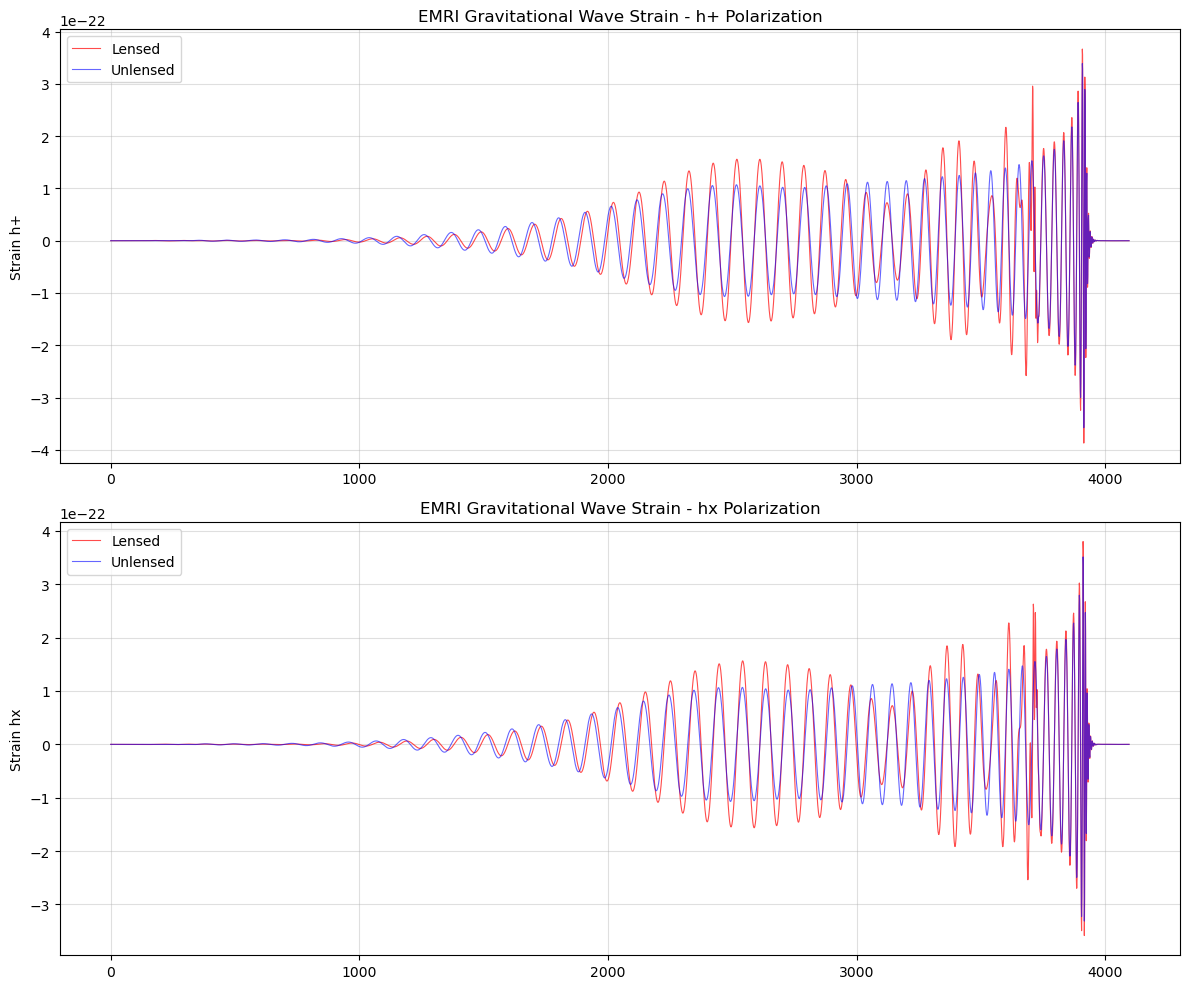

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot h+ polarization
axes[0].plot(old_waveform["hp_TD_Lensed"], 'r-', linewidth=0.8, label='Lensed', alpha=0.7)
axes[0].plot(old_waveform["hp_TD_Unlensed"], 'b-', linewidth=0.8, label='Unlensed', alpha=0.6)
axes[0].set_ylabel('Strain h+')
axes[0].set_title('EMRI Gravitational Wave Strain - h+ Polarization')
axes[0].grid(True, alpha=0.4)
axes[0].legend()
print(old_waveform["hp_TD_Unlensed"].shape, old_waveform["hp_TD_Lensed"].shape)
# Plot hx (cross) polarization
axes[1].plot(old_waveform["hc_TD_Lensed"], 'r-', linewidth=0.8, label='Lensed', alpha=0.7)
axes[1].plot(old_waveform["hc_TD_Unlensed"], 'b-', linewidth=0.8, label='Unlensed', alpha=0.6)
axes[1].set_ylabel('Strain hx')
axes[1].set_title('EMRI Gravitational Wave Strain - hx Polarization')
axes[1].grid(True, alpha=0.4)
axes[1].legend()

plt.tight_layout()
plt.show()